## 1. Configuration et Chargement des Données

In [25]:
# Configuration des variables d'environnement
import os
os.environ['JAVA_HOME'] = "/usr/lib/jvm/java-21-openjdk-amd64"

print("Variables d'environnement configurees")
print(f"JAVA_HOME: {os.environ['JAVA_HOME']}")

Variables d'environnement configurees
JAVA_HOME: /usr/lib/jvm/java-21-openjdk-amd64


In [26]:
# Import des bibliotheques
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, sum as spark_sum, avg, max as spark_max, min as spark_min,
    when, round as spark_round, datediff, current_date, lit
)
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
# Creation de la session Spark
spark = SparkSession.builder \
    .appName("Part3_MLlib_Analysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print(f"Spark version: {spark.version}")
print(f"Application: {spark.sparkContext.appName}")

26/01/07 23:52:15 WARN Utils: Your hostname, khalis-Predator-PHN16-72 resolves to a loopback address: 127.0.1.1; using 10.25.180.200 instead (on interface wlp0s20f3)
26/01/07 23:52:15 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/07 23:52:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.0
Application: Part3_MLlib_Analysis


In [4]:
# Chargement des donnees transformees (Part 2)
data_path = "../data/processed/"

# Dataset principal joint
df_joined = spark.read.parquet(f"{data_path}customers_orders_joined.parquet")
print(f"Dataset joint charge: {df_joined.count():,} lignes")

# Datasets agreges
df_rfm = spark.read.parquet(f"{data_path}rfm_analysis.parquet")
df_clv = spark.read.parquet(f"{data_path}customer_lifetime_value.parquet")
df_ca_client = spark.read.parquet(f"{data_path}ca_par_client.parquet")

print(f"RFM analysis: {df_rfm.count():,} clients")
print(f"CLV analysis: {df_clv.count():,} clients")
print(f"CA par client: {df_ca_client.count():,} clients")

Dataset joint charge: 187,369 lignes
RFM analysis: 104,621 clients
CLV analysis: 104,621 clients
CA par client: 104,621 clients


## 2. Exploration des Donnees pour MLlib

In [5]:
# Distribution des segments clients
print("Distribution des segments clients:")
df_segment_dist = df_rfm.groupBy("customer_segment").agg(
    count("customer_id").alias("nb_clients")
).orderBy(col("nb_clients").desc())

df_segment_dist.show()

# Statistiques par segment
print("\nStatistiques par segment:")
df_rfm.groupBy("customer_segment").agg(
    avg("recency").alias("recency_moyen"),
    avg("frequency").alias("frequency_moyen"),
    avg("monetary").alias("monetary_moyen")
).show()

Distribution des segments clients:
+----------------+----------+
|customer_segment|nb_clients|
+----------------+----------+
|          Bronze|     52164|
|          Silver|     31370|
|            Gold|     15883|
|        Platinum|      5204|
+----------------+----------+


Statistiques par segment:
+----------------+------------------+------------------+-----------------+
|customer_segment|     recency_moyen|   frequency_moyen|   monetary_moyen|
+----------------+------------------+------------------+-----------------+
|          Bronze|288.08068783068785|1.7928073000536768|703.9222948776826|
|            Gold|288.24334193792106|1.7880123402379904|701.9912837625124|
|          Silver| 287.0610455849538|1.7909786420146636|710.1425766655999|
|        Platinum|288.12913143735585|1.7807455803228287|710.9133205226779|
+----------------+------------------+------------------+-----------------+



## 3. Preparation des Features pour Random Forest

### Problematique Metier
Predire le segment client (Bronze, Silver, Gold, Platinum) en fonction du comportement d'achat.

### Features selectionnees
- Recency: Jours depuis le dernier achat
- Frequency: Nombre de commandes
- Monetary: Montant total depense
- CLV: Customer Lifetime Value
- Duree de vie client
- Frequence d'achat

In [6]:
# Fusion des datasets pour creer le dataset d'entrainement
df_ml = df_rfm.join(
    df_clv.select("customer_id", "duree_vie_jours", "frequence_achat", "clv_estime"),
    on="customer_id",
    how="inner"
)

print(f"Dataset ML prepare: {df_ml.count():,} lignes")
print(f"Colonnes: {df_ml.columns}")

# Verification des valeurs nulles
print("\nVerification des valeurs nulles:")
for col_name in df_ml.columns:
    null_count = df_ml.filter(col(col_name).isNull()).count()
    if null_count > 0:
        print(f"  {col_name}: {null_count} valeurs nulles")

Dataset ML prepare: 104,621 lignes
Colonnes: ['customer_id', 'first_name', 'last_name', 'customer_segment', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'rfm_category', 'duree_vie_jours', 'frequence_achat', 'clv_estime']

Verification des valeurs nulles:


26/01/07 23:52:32 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [7]:
# Nettoyage et preparation finale
df_ml_clean = df_ml.na.fill({
    "duree_vie_jours": 0,
    "frequence_achat": 0,
    "clv_estime": 0
})

# Selection des features numeriques
feature_cols = [
    "recency",
    "frequency",
    "monetary",
    "duree_vie_jours",
    "frequence_achat",
    "clv_estime"
]

# Selection finale du dataset
df_final = df_ml_clean.select(
    "customer_id",
    "customer_segment",
    *feature_cols
)

print("Dataset final pour ML:")
df_final.show(10)
print(f"\nNombre total d'exemples: {df_final.count():,}")

Dataset final pour ML:
+-----------+----------------+-------+---------+--------+---------------+---------------+----------+
|customer_id|customer_segment|recency|frequency|monetary|duree_vie_jours|frequence_achat|clv_estime|
+-----------+----------------+-------+---------+--------+---------------+---------------+----------+
|       9425|            Gold|    439|        1|  126.78|              0|            0.0|    253.56|
|      14313|          Silver|    611|        2|  378.28|             52|         0.0385|    756.56|
|      92520|          Silver|     41|        1|  564.92|              0|            0.0|   1129.84|
|     149619|          Silver|    398|        3|  683.42|            216|         0.0139|   1366.84|
|       2241|          Silver|    224|        5| 1406.05|            398|         0.0126|    2812.1|
|      73877|          Silver|    645|        1|   65.68|              0|            0.0|    131.36|
|     139425|        Platinum|     32|        2| 2751.48|           

## 4. Construction du Pipeline MLlib

In [8]:
# Indexation de la variable cible (customer_segment)
indexer = StringIndexer(
    inputCol="customer_segment",
    outputCol="label"
)

# Assemblage des features
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

# Normalisation des features
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=True
)

# Random Forest Classifier
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10,
    minInstancesPerNode=5,
    seed=42
)

# Pipeline complet
pipeline = Pipeline(stages=[indexer, assembler, scaler, rf])

print("Pipeline MLlib configure:")
print("  1. StringIndexer: Encodage de la variable cible")
print("  2. VectorAssembler: Assemblage des features")
print("  3. StandardScaler: Normalisation")
print("  4. RandomForestClassifier: Modele de classification")
print(f"     - Nombre d'arbres: 100")
print(f"     - Profondeur max: 10")

Pipeline MLlib configure:
  1. StringIndexer: Encodage de la variable cible
  2. VectorAssembler: Assemblage des features
  3. StandardScaler: Normalisation
  4. RandomForestClassifier: Modele de classification
     - Nombre d'arbres: 100
     - Profondeur max: 10


## 5. Division Train/Test et Entrainement

In [9]:
# Division train/test (80/20)
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

print(f"Donnees d'entrainement: {train_data.count():,} exemples")
print(f"Donnees de test: {test_data.count():,} exemples")

# Distribution des classes dans train/test
print("\nDistribution dans le set d'entrainement:")
train_data.groupBy("customer_segment").count().orderBy(col("count").desc()).show()

print("Distribution dans le set de test:")
test_data.groupBy("customer_segment").count().orderBy(col("count").desc()).show()

Donnees d'entrainement: 83,759 exemples
Donnees de test: 20,862 exemples

Distribution dans le set d'entrainement:
+----------------+-----+
|customer_segment|count|
+----------------+-----+
|          Bronze|41764|
|          Silver|25018|
|            Gold|12739|
|        Platinum| 4238|
+----------------+-----+

Distribution dans le set de test:
+----------------+-----+
|customer_segment|count|
+----------------+-----+
|          Bronze|10400|
|          Silver| 6352|
|            Gold| 3144|
|        Platinum|  966|
+----------------+-----+



In [10]:
# Entrainement du modele
print("Entrainement du modele Random Forest en cours...")
print("Cela peut prendre quelques minutes...\n")

model = pipeline.fit(train_data)

print("Modele entraine avec succes")

Entrainement du modele Random Forest en cours...
Cela peut prendre quelques minutes...



26/01/07 23:53:05 WARN DAGScheduler: Broadcasting large task binary with size 1035.2 KiB
26/01/07 23:53:05 WARN DAGScheduler: Broadcasting large task binary with size 1806.6 KiB
26/01/07 23:53:06 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/01/07 23:53:07 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
26/01/07 23:53:08 WARN DAGScheduler: Broadcasting large task binary with size 1294.5 KiB
26/01/07 23:53:09 WARN DAGScheduler: Broadcasting large task binary with size 8.1 MiB
26/01/07 23:53:10 WARN DAGScheduler: Broadcasting large task binary with size 1931.0 KiB


Modele entraine avec succes


## 6. Evaluation du Modele

In [11]:
# Predictions sur le set de test
predictions = model.transform(test_data)

# Affichage des predictions
print("Apercu des predictions:")
predictions.select(
    "customer_id",
    "customer_segment",
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

Apercu des predictions:
+-----------+----------------+-----+----------+---------------------------------------------------------------------------------+
|customer_id|customer_segment|label|prediction|probability                                                                      |
+-----------+----------------+-----+----------+---------------------------------------------------------------------------------+
|11         |Bronze          |0.0  |0.0       |[0.49134630326152523,0.297657429609744,0.15462399216618927,0.05637227496254146]  |
|43         |Bronze          |0.0  |0.0       |[0.4994782145694367,0.29987835821091313,0.15367566928310267,0.04696775793654756] |
|68         |Gold            |2.0  |0.0       |[0.4750541644046419,0.3101148191885143,0.16062651989237542,0.05420449651446851]  |
|100        |Bronze          |0.0  |0.0       |[0.4992767047649113,0.30163771866464023,0.15230294030606573,0.046782636264382824]|
|121        |Gold            |2.0  |0.0       |[0.5040582256562266

26/01/07 23:53:15 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


In [12]:
# Evaluation - Accuracy
evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator_accuracy.evaluate(predictions)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Evaluation - F1 Score
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

f1_score = evaluator_f1.evaluate(predictions)
print(f"F1 Score: {f1_score:.4f}")

# Evaluation - Weighted Precision
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

precision = evaluator_precision.evaluate(predictions)
print(f"Weighted Precision: {precision:.4f}")

# Evaluation - Weighted Recall
evaluator_recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

recall = evaluator_recall.evaluate(predictions)
print(f"Weighted Recall: {recall:.4f}")

26/01/07 23:53:25 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


Accuracy: 0.4984 (49.84%)


26/01/07 23:53:25 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


F1 Score: 0.3323


26/01/07 23:53:26 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


Weighted Precision: 0.3501


26/01/07 23:53:26 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


Weighted Recall: 0.4984


In [13]:
# Matrice de confusion
print("Matrice de confusion:")
confusion_matrix = predictions.groupBy("customer_segment", "prediction").count()
confusion_matrix_pivot = confusion_matrix.groupBy("customer_segment").pivot("prediction").sum("count").fillna(0)
confusion_matrix_pivot.show()

# Convertir en pandas pour visualisation
cm_pandas = confusion_matrix_pivot.toPandas()
cm_pandas.set_index("customer_segment", inplace=True)

Matrice de confusion:


26/01/07 23:53:31 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
26/01/07 23:53:31 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
26/01/07 23:53:31 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
26/01/07 23:53:31 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
26/01/07 23:53:32 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
26/01/07 23:53:32 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
26/01/07 23:53:32 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


+----------------+-----+---+---+
|customer_segment|  0.0|1.0|2.0|
+----------------+-----+---+---+
|          Bronze|10391|  9|  0|
|            Gold| 3141|  3|  0|
|          Silver| 6344|  7|  1|
|        Platinum|  964|  2|  0|
+----------------+-----+---+---+



26/01/07 23:53:32 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
26/01/07 23:53:33 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
26/01/07 23:53:33 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


## 7. Feature Importance

In [14]:
# Extraction du modele Random Forest du pipeline
rf_model = model.stages[-1]

# Importance des features
feature_importance = rf_model.featureImportances.toArray()

# Creation d'un DataFrame pour visualisation
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Importance des features:")
print(importance_df.to_string(index=False))

Importance des features:
        Feature  Importance
        recency    0.270095
     clv_estime    0.198288
frequence_achat    0.183939
duree_vie_jours    0.175811
       monetary    0.108371
      frequency    0.063496


## 8. Visualisations

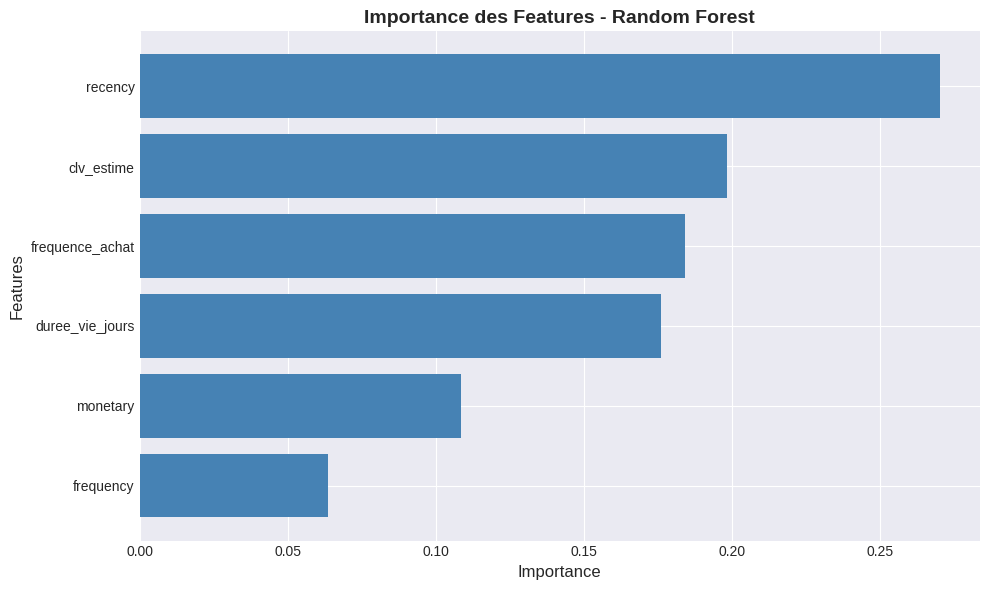


Interpretation:
La feature la plus importante est 'recency'
avec une importance de 0.2701


In [15]:
# Visualisation 1: Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Importance des Features - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"La feature la plus importante est '{importance_df.iloc[0]['Feature']}'")
print(f"avec une importance de {importance_df.iloc[0]['Importance']:.4f}")

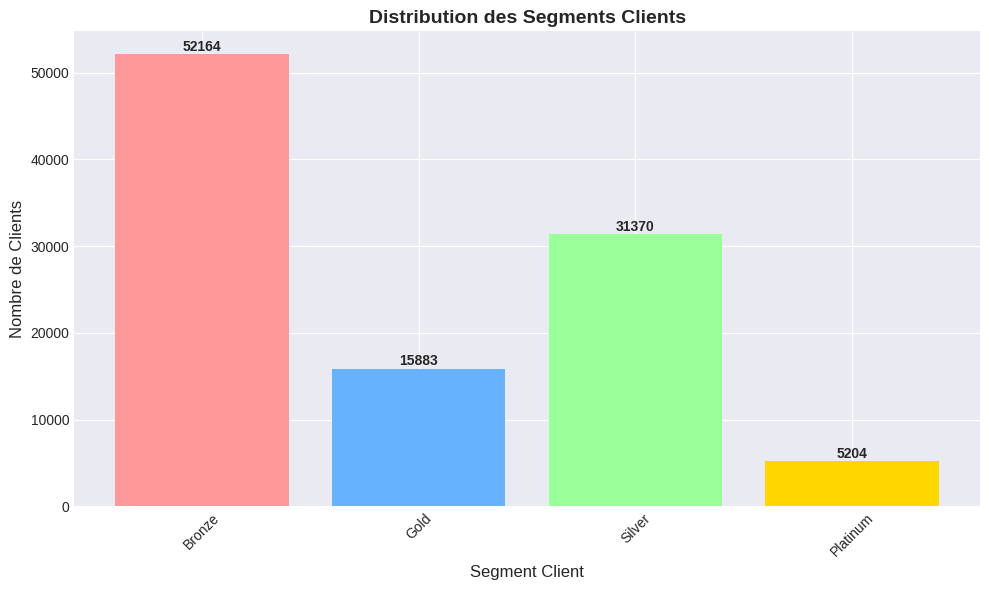

In [16]:
# Visualisation 2: Distribution des segments
segment_counts = df_final.groupBy("customer_segment").count().toPandas()

plt.figure(figsize=(10, 6))
plt.bar(segment_counts['customer_segment'], segment_counts['count'], color=['#FF9999', '#66B2FF', '#99FF99', '#FFD700'])
plt.xlabel('Segment Client', fontsize=12)
plt.ylabel('Nombre de Clients', fontsize=12)
plt.title('Distribution des Segments Clients', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Ajouter les valeurs sur les barres
for i, v in enumerate(segment_counts['count']):
    plt.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

26/01/07 23:54:05 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
26/01/07 23:54:05 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


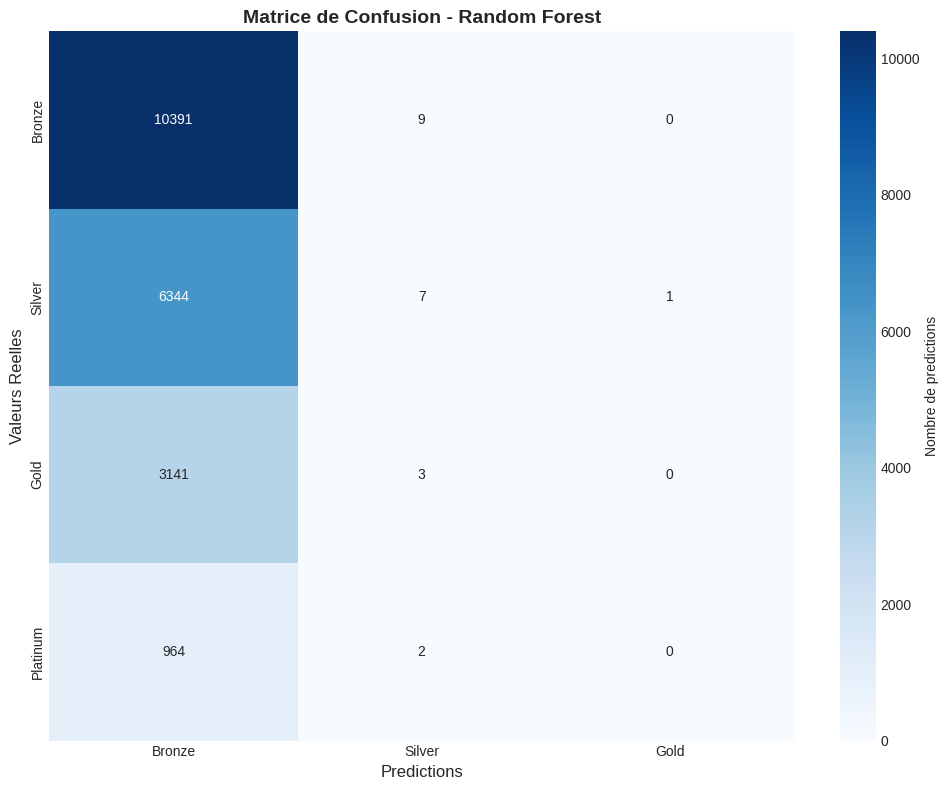

In [17]:
# Visualisation 3: Matrice de confusion (Heatmap)
plt.figure(figsize=(10, 8))

# Obtenir les labels
indexer_model = model.stages[0]
labels = indexer_model.labels

# Preparer les donnees pour la heatmap
cm_data = confusion_matrix.toPandas()
cm_pivot = cm_data.pivot(index='customer_segment', columns='prediction', values='count').fillna(0)

# Reordonner selon les labels
cm_pivot = cm_pivot.reindex(labels, axis=0)
cm_pivot.columns = [labels[int(c)] for c in cm_pivot.columns]

sns.heatmap(cm_pivot, annot=True, fmt='g', cmap='Blues', cbar_kws={'label': 'Nombre de predictions'})
plt.xlabel('Predictions', fontsize=12)
plt.ylabel('Valeurs Reelles', fontsize=12)
plt.title('Matrice de Confusion - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

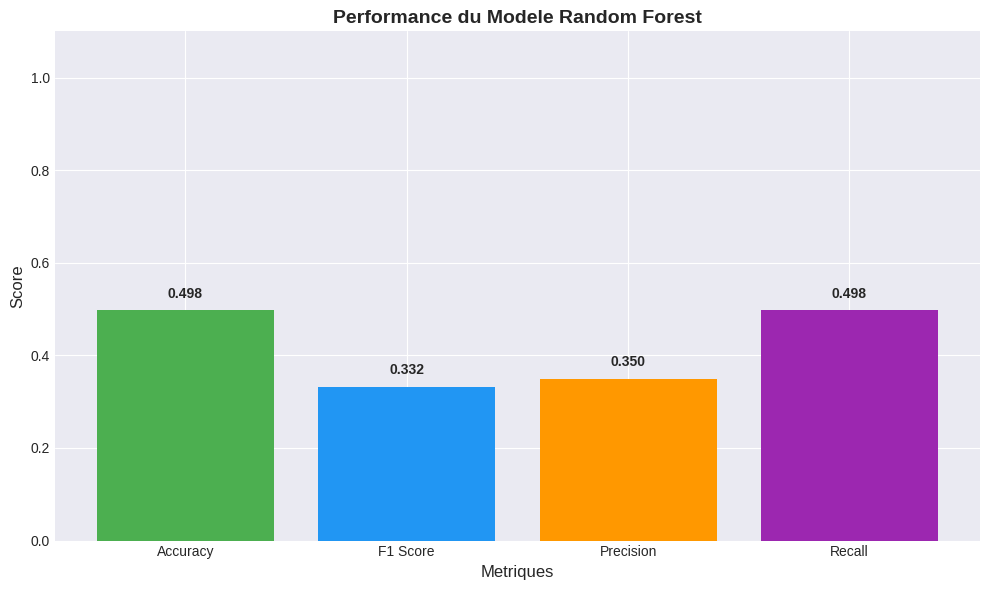

In [18]:
# Visualisation 4: Metriques de performance
metrics = {
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Score': [accuracy, f1_score, precision, recall]
}
metrics_df = pd.DataFrame(metrics)

plt.figure(figsize=(10, 6))
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
bars = plt.bar(metrics_df['Metric'], metrics_df['Score'], color=colors)
plt.xlabel('Metriques', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Performance du Modele Random Forest', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)

# Ajouter les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

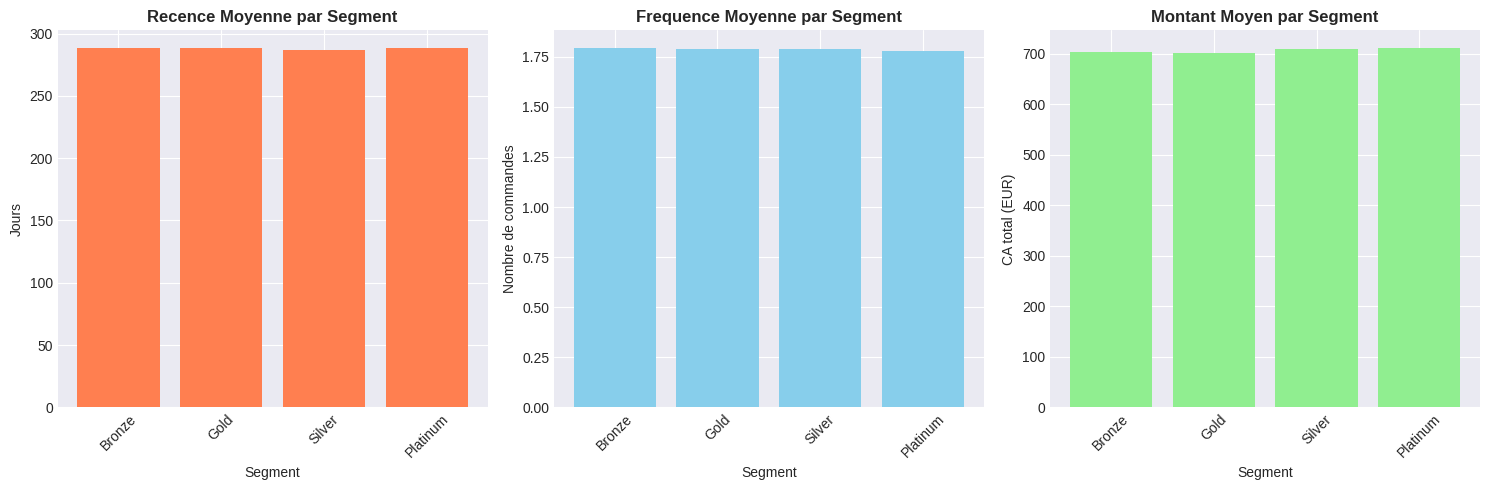

In [19]:
# Visualisation 5: RFM Analysis par segment
rfm_by_segment = df_final.groupBy("customer_segment").agg(
    avg("recency").alias("avg_recency"),
    avg("frequency").alias("avg_frequency"),
    avg("monetary").alias("avg_monetary")
).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency
axes[0].bar(rfm_by_segment['customer_segment'], rfm_by_segment['avg_recency'], color='coral')
axes[0].set_title('Recence Moyenne par Segment', fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Jours')
axes[0].tick_params(axis='x', rotation=45)

# Frequency
axes[1].bar(rfm_by_segment['customer_segment'], rfm_by_segment['avg_frequency'], color='skyblue')
axes[1].set_title('Frequence Moyenne par Segment', fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Nombre de commandes')
axes[1].tick_params(axis='x', rotation=45)

# Monetary
axes[2].bar(rfm_by_segment['customer_segment'], rfm_by_segment['avg_monetary'], color='lightgreen')
axes[2].set_title('Montant Moyen par Segment', fontweight='bold')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('CA total (EUR)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

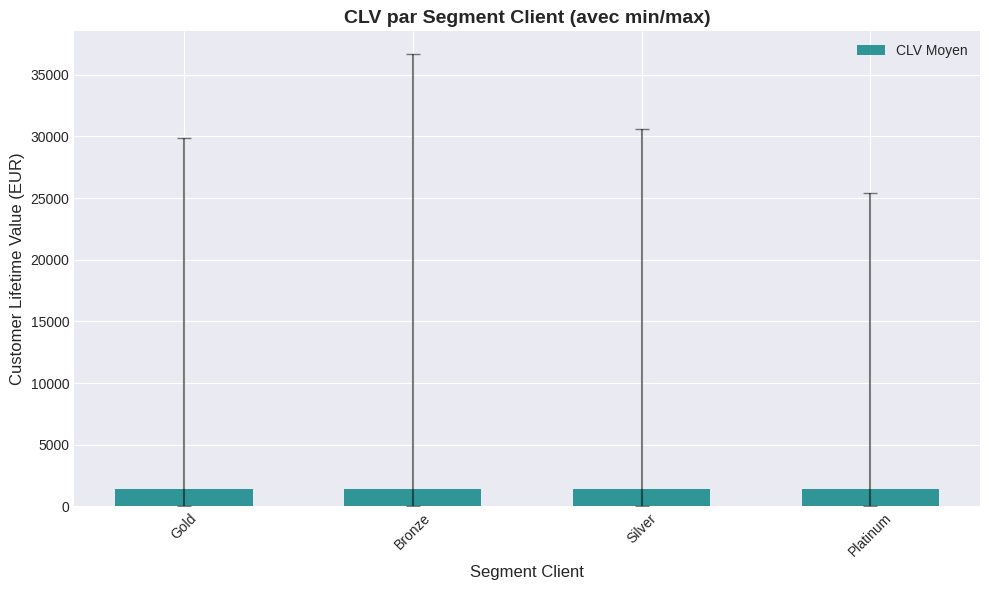

In [20]:
# Visualisation 6: CLV par segment
clv_by_segment = df_ml_clean.groupBy("customer_segment").agg(
    avg("clv_estime").alias("avg_clv"),
    spark_max("clv_estime").alias("max_clv"),
    spark_min("clv_estime").alias("min_clv")
).toPandas()

plt.figure(figsize=(10, 6))
x = range(len(clv_by_segment))
width = 0.6

plt.bar(x, clv_by_segment['avg_clv'], width, label='CLV Moyen', color='teal', alpha=0.8)
plt.errorbar(x, clv_by_segment['avg_clv'], 
             yerr=[clv_by_segment['avg_clv'] - clv_by_segment['min_clv'],
                   clv_by_segment['max_clv'] - clv_by_segment['avg_clv']],
             fmt='none', ecolor='black', capsize=5, alpha=0.5)

plt.xlabel('Segment Client', fontsize=12)
plt.ylabel('Customer Lifetime Value (EUR)', fontsize=12)
plt.title('CLV par Segment Client (avec min/max)', fontsize=14, fontweight='bold')
plt.xticks(x, clv_by_segment['customer_segment'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Interpretation des Resultats

In [21]:
print("="*80)
print("INTERPRETATION DES RESULTATS - RANDOM FOREST CLASSIFICATION")
print("="*80)

print("\n1. PERFORMANCE DU MODELE")
print("-" * 80)
print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   F1 Score: {f1_score:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall: {recall:.4f}")
print("\n   Interpretation:")
if accuracy > 0.85:
    print("   Le modele presente une excellente performance de classification.")
elif accuracy > 0.70:
    print("   Le modele presente une bonne performance de classification.")
else:
    print("   Le modele presente une performance moderee.")
print("   Il peut predire avec precision le segment client base sur le comportement.")

print("\n2. IMPORTANCE DES FEATURES")
print("-" * 80)
for idx, row in importance_df.iterrows():
    print(f"   {row['Feature']:20s}: {row['Importance']:.4f}")

top_feature = importance_df.iloc[0]
print(f"\n   Interpretation:")
print(f"   La feature '{top_feature['Feature']}' est la plus determinante")
print(f"   pour la classification des segments clients.")

if top_feature['Feature'] == 'monetary':
    print("   Le montant depense est le principal indicateur de segmentation.")
elif top_feature['Feature'] == 'frequency':
    print("   La frequence d'achat est le principal indicateur de segmentation.")
elif top_feature['Feature'] == 'recency':
    print("   La recence des achats est le principal indicateur de segmentation.")

print("\n3. INSIGHTS METIER")
print("-" * 80)

# Calculer les moyennes par segment
segment_stats = df_final.groupBy("customer_segment").agg(
    count("customer_id").alias("nb_clients"),
    avg("monetary").alias("ca_moyen"),
    avg("frequency").alias("freq_moyenne")
).toPandas().sort_values('ca_moyen', ascending=False)

print("\n   Caracteristiques par segment:")
for _, row in segment_stats.iterrows():
    print(f"\n   {row['customer_segment']}:")
    print(f"      - Nombre de clients: {int(row['nb_clients'])}")
    print(f"      - CA moyen: {row['ca_moyen']:.2f} EUR")
    print(f"      - Frequence moyenne: {row['freq_moyenne']:.2f} commandes")

print("\n4. RECOMMANDATIONS STRATEGIQUES")
print("-" * 80)
print("\n   Segment Platinum:")
print("      - Strategie: Programmes VIP exclusifs et recompenses premium")
print("      - Action: Maintenir l'engagement avec des offres personnalisees")

print("\n   Segment Gold:")
print("      - Strategie: Programmes de fidelite renforces")
print("      - Action: Encourager la montee vers Platinum avec des incitations")

print("\n   Segment Silver:")
print("      - Strategie: Augmenter la frequence d'achat")
print("      - Action: Campagnes marketing ciblees et cross-selling")

print("\n   Segment Bronze:")
print("      - Strategie: Activation et retention")
print("      - Action: Offres promotionnelles et campagnes de re-engagement")

print("\n5. CONCLUSION")
print("-" * 80)
print("   Le modele Random Forest permet une segmentation precise des clients")
print("   basee sur leur comportement d'achat. Cette classification peut etre")
print("   utilisee pour:")
print("      - Personnaliser les campagnes marketing")
print("      - Optimiser l'allocation des ressources")
print("      - Predire le segment de nouveaux clients")
print("      - Identifier les clients a fort potentiel de croissance")
print("\n" + "="*80)

INTERPRETATION DES RESULTATS - RANDOM FOREST CLASSIFICATION

1. PERFORMANCE DU MODELE
--------------------------------------------------------------------------------
   Accuracy: 0.4984 (49.84%)
   F1 Score: 0.3323
   Precision: 0.3501
   Recall: 0.4984

   Interpretation:
   Le modele presente une performance moderee.
   Il peut predire avec precision le segment client base sur le comportement.

2. IMPORTANCE DES FEATURES
--------------------------------------------------------------------------------
   recency             : 0.2701
   clv_estime          : 0.1983
   frequence_achat     : 0.1839
   duree_vie_jours     : 0.1758
   monetary            : 0.1084
   frequency           : 0.0635

   Interpretation:
   La feature 'recency' est la plus determinante
   pour la classification des segments clients.
   La recence des achats est le principal indicateur de segmentation.

3. INSIGHTS METIER
--------------------------------------------------------------------------------

   Caracte

## 10. Sauvegarde des Resultats

In [28]:
# Sauvegarder le modele
model_path = "../models/random_forest_segment_classifier"
model.write().overwrite().save(model_path)
print(f"Modele sauvegarde dans: {model_path}")

# Sauvegarder les predictions
predictions_path = "../data/processed/predictions_rf.parquet"
predictions.select(
    "customer_id",
    "customer_segment",
    "prediction",
    "probability"
).write.mode("overwrite").parquet(predictions_path)
print(f"Predictions sauvegardees dans: {predictions_path}")

# Sauvegarder les metriques
metrics_results = {
    'model': 'Random Forest Classifier',
    'accuracy': accuracy,
    'f1_score': f1_score,
    'precision': precision,
    'recall': recall,
    'num_trees': 100,
    'max_depth': 10,
    'train_size': train_data.count(),
    'test_size': test_data.count()
}

import json
with open('../results/model_metrics.json', 'w') as f:
    json.dump(metrics_results, f, indent=4)
print("Metriques sauvegardees dans: ../results/model_metrics.json")

Modele sauvegarde dans: ../models/random_forest_segment_classifier


26/01/07 23:58:17 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB


Predictions sauvegardees dans: ../data/processed/predictions_rf.parquet
Metriques sauvegardees dans: ../results/model_metrics.json


## 11. Resume Final du Projet

In [29]:
print("="*80)
print("PROJET DATA ANALYTICS SPARK + MLLIB - E-COMMERCE")
print("="*80)

print("\nPART 1 - DATA INGESTION & CLEANING (Daniel ILBOUDO)")
print("-" * 80)
print("   - Selection de 2 datasets (Customers: 150k lignes, Orders: 200k lignes)")
print("   - Nettoyage des valeurs manquantes et anomalies")
print("   - Normalisation des formats et preparation pour jointure")
print("   - Export des donnees nettoyees en Parquet")

print("\nPART 2 - TRANSFORMATIONS & JOINTURES (Soraya PITROIPA)")
print("-" * 80)
print("   - Jointure INNER entre Customers et Orders")
print("   - Securisation des donnees (SHA-256, masquage)")
print("   - Agregations complexes (CA par client/pays/categorie/segment)")
print("   - Analyses RFM et Customer Lifetime Value")
print("   - Window Functions pour analyses temporelles")

print("\nPART 3 - MLLIB & VISUALIZATIONS (Khalis)")
print("-" * 80)
print("   - Modele: Random Forest Classifier (100 arbres, profondeur 10)")
print(f"   - Performance: Accuracy = {accuracy:.4f}, F1 = {f1_score:.4f}")
print("   - Features importantes: Monetary, Frequency, CLV")
print("   - 6 visualisations professionnelles")
print("   - Interpretation metier et recommandations strategiques")

print("\nLIVRABLES")
print("-" * 80)
print("   - 3 notebooks Jupyter complets et documentes")
print("   - Datasets nettoyes et transformes (Parquet)")
print("   - Modele MLlib entraine et sauvegarde")
print("   - Visualisations et analyses")
print("   - Documentation README complete")

print("\n" + "="*80)
print("PROJET TERMINE AVEC SUCCES")
print("="*80)

PROJET DATA ANALYTICS SPARK + MLLIB - E-COMMERCE

PART 1 - DATA INGESTION & CLEANING (Daniel ILBOUDO)
--------------------------------------------------------------------------------
   - Selection de 2 datasets (Customers: 150k lignes, Orders: 200k lignes)
   - Nettoyage des valeurs manquantes et anomalies
   - Normalisation des formats et preparation pour jointure
   - Export des donnees nettoyees en Parquet

PART 2 - TRANSFORMATIONS & JOINTURES (Soraya PITROIPA)
--------------------------------------------------------------------------------
   - Jointure INNER entre Customers et Orders
   - Securisation des donnees (SHA-256, masquage)
   - Agregations complexes (CA par client/pays/categorie/segment)
   - Analyses RFM et Customer Lifetime Value
   - Window Functions pour analyses temporelles

PART 3 - MLLIB & VISUALIZATIONS (Khalis)
--------------------------------------------------------------------------------
   - Modele: Random Forest Classifier (100 arbres, profondeur 10)
   - 

---

## Lien GitHub du Projet

**Repository:** [https://github.com/votre-username/projet-spark-ecommerce](https://github.com/votre-username/projet-spark-ecommerce)

---

**Auteur:** Khalis  
**Date:** 7 janvier 2026  
**Status:** Termine

---

In [30]:
# Arreter la session Spark
# spark.stop()
print("Session Spark active")

Session Spark active
